# Convolutional Neural Networks from Scratch with NumPy

This notebook walks through the basic ideas behind **convolutional neural networks** and implements two examples using NumPy only for the neural-network computations.

We will build:

1. A small **2D convolutional neural network** for image classification on MNIST digits.
2. A small **1D convolutional neural network** for time-series classification.

The goal is not to compete with PyTorch, TensorFlow, or JAX. The goal is to make the mechanics visible:

- convolutional filters,
- nonlinear activation functions,
- max pooling,
- flattening,
- fully connected output layers,
- softmax classification,
- cross-entropy loss,
- and backpropagation through convolutional layers.

The style is intentionally similar to a from-scratch NumPy neural-network script: dictionaries/classes store parameters, forward passes cache intermediate values, and backward passes compute gradients manually.

## 1. Why CNNs?

A dense neural network treats every input coordinate as unrelated. For images, this means every pixel has a separate weight to every neuron. That ignores the fact that nearby pixels often form local patterns such as edges, corners, curves, or textures.

A convolutional neural network uses small filters that slide across the input. The same filter weights are reused at every spatial location. This gives CNNs two important advantages:

1. **Locality:** each filter looks at a small neighborhood.
2. **Weight sharing:** the same filter detects the same pattern wherever it appears.

For a 2D image, a convolutional layer maps an input tensor

$$
X \in \mathbb{R}^{N \times C_{in} \times H \times W}
$$

to an output tensor

$$
Y \in \mathbb{R}^{N \times C_{out} \times H_{out} \times W_{out}}.
$$

Here:

- \(N\) is the number of examples in a batch,
- \(C_{in}\) is the number of input channels,
- \(C_{out}\) is the number of filters,
- \(H,W\) are height and width.

For a valid convolution with no padding and stride 1,

$$
H_{out} = H - K_h + 1, \qquad W_{out} = W - K_w + 1.
$$

In [1]:
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 2. Utility functions

For multi-class classification, we will use:

- one-hot labels,
- softmax probabilities,
- cross-entropy loss,
- classification accuracy.

The softmax function maps raw scores, also called logits, to class probabilities:

$$
\mathrm{softmax}(z)_k = \frac{e^{z_k}}{\sum_j e^{z_j}}.
$$

The cross-entropy loss for one observation is

$$
\ell(\hat{y}, y) = -\sum_{k=1}^K y_k \log(\hat{y}_k),
$$

where $y$ is the one-hot encoded true label.

In [2]:
def one_hot(y, num_classes):
    Y = np.zeros((len(y), num_classes))
    Y[np.arange(len(y)), y.astype(int)] = 1.0
    return Y


def softmax(logits):
    # Subtract max for numerical stability.
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


def cross_entropy_loss(probs, Y):
    eps = 1e-12
    return -np.mean(np.sum(Y * np.log(probs + eps), axis=1))


def accuracy_from_logits(logits, y):
    preds = np.argmax(logits, axis=1)
    return np.mean(preds == y)


def get_minibatches(X, y, batch_size, seed=None):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    perm = rng.permutation(n)
    for start in range(0, n, batch_size):
        idx = perm[start:start + batch_size]
        yield X[idx], y[idx]

## 3. Building blocks for a 2D CNN

We now implement the layers needed for a small MNIST classifier:

1. `Conv2D`
2. `ReLU`
3. `MaxPool2D`
4. `Flatten`
5. `Dense`
6. `SoftmaxCrossEntropy`

The convolution implementation below uses an `im2col` transformation. Instead of explicitly sliding the filter across every image location with many nested loops, `im2col` unfolds all local patches into columns. Then convolution becomes a matrix multiplication.

This is still a teaching implementation, not an optimized production implementation.

In [3]:
def im2col_2d(X, kh, kw, stride=1, padding=0):
    '''Convert image batches into columns of local patches.

    X has shape (N, C, H, W).
    Output has shape (C * kh * kw, N * H_out * W_out).
    '''
    N, C, H, W = X.shape

    if padding > 0:
        X_pad = np.pad(
            X,
            ((0, 0), (0, 0), (padding, padding), (padding, padding)),
            mode="constant"
        )
    else:
        X_pad = X

    H_pad, W_pad = X_pad.shape[2], X_pad.shape[3]
    H_out = (H_pad - kh) // stride + 1
    W_out = (W_pad - kw) // stride + 1

    cols = np.zeros((C * kh * kw, N * H_out * W_out))
    col_idx = 0

    for n in range(N):
        for i in range(H_out):
            for j in range(W_out):
                h_start = i * stride
                w_start = j * stride
                patch = X_pad[n, :, h_start:h_start + kh, w_start:w_start + kw]
                cols[:, col_idx] = patch.reshape(-1)
                col_idx += 1

    return cols, H_out, W_out


def col2im_2d(cols, X_shape, kh, kw, stride=1, padding=0):
    '''Reverse im2col by accumulating column gradients back into image shape.'''
    N, C, H, W = X_shape

    H_pad = H + 2 * padding
    W_pad = W + 2 * padding
    H_out = (H_pad - kh) // stride + 1
    W_out = (W_pad - kw) // stride + 1

    X_pad_grad = np.zeros((N, C, H_pad, W_pad))
    col_idx = 0

    for n in range(N):
        for i in range(H_out):
            for j in range(W_out):
                h_start = i * stride
                w_start = j * stride
                patch_grad = cols[:, col_idx].reshape(C, kh, kw)
                X_pad_grad[n, :, h_start:h_start + kh, w_start:w_start + kw] += patch_grad
                col_idx += 1

    if padding > 0:
        return X_pad_grad[:, :, padding:-padding, padding:-padding]
    return X_pad_grad

In [4]:
class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, seed=0):
        rng = np.random.default_rng(seed)
        if isinstance(kernel_size, int):
            kh = kw = kernel_size
        else:
            kh, kw = kernel_size

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kh = kh
        self.kw = kw
        self.stride = stride
        self.padding = padding

        # Xavier-style initialization.
        fan_in = in_channels * kh * kw
        fan_out = out_channels * kh * kw
        limit = np.sqrt(6.0 / (fan_in + fan_out))
        self.W = rng.uniform(-limit, limit, size=(out_channels, in_channels, kh, kw))
        self.b = np.zeros((out_channels, 1))

    def forward(self, X):
        self.X_shape = X.shape
        self.X_cols, self.H_out, self.W_out = im2col_2d(
            X, self.kh, self.kw, self.stride, self.padding
        )
        W_cols = self.W.reshape(self.out_channels, -1)
        out_cols = W_cols @ self.X_cols + self.b

        N = X.shape[0]
        out = out_cols.reshape(self.out_channels, N, self.H_out, self.W_out)
        out = out.transpose(1, 0, 2, 3)
        return out

    def backward(self, dout):
        N = dout.shape[0]
        dout_cols = dout.transpose(1, 0, 2, 3).reshape(self.out_channels, -1)

        self.dW = dout_cols @ self.X_cols.T
        self.dW = self.dW.reshape(self.W.shape) / N
        self.db = np.sum(dout_cols, axis=1, keepdims=True) / N

        W_cols = self.W.reshape(self.out_channels, -1)
        dX_cols = W_cols.T @ dout_cols
        dX = col2im_2d(dX_cols, self.X_shape, self.kh, self.kw, self.stride, self.padding)
        return dX

    def step(self, learning_rate):
        self.W -= learning_rate * self.dW
        self.b -= learning_rate * self.db


class ReLU:
    def forward(self, X):
        self.mask = X > 0
        return np.maximum(0, X)

    def backward(self, dout):
        return dout * self.mask

    def step(self, learning_rate):
        pass


class MaxPool2D:
    def __init__(self, pool_size=2, stride=2):
        self.pool_size = pool_size
        self.stride = stride

    def forward(self, X):
        self.X = X
        N, C, H, W = X.shape
        ph = pw = self.pool_size
        H_out = (H - ph) // self.stride + 1
        W_out = (W - pw) // self.stride + 1

        out = np.zeros((N, C, H_out, W_out))
        self.max_indices = {}

        for n in range(N):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * self.stride
                        w_start = j * self.stride
                        window = X[n, c, h_start:h_start + ph, w_start:w_start + pw]
                        out[n, c, i, j] = np.max(window)
                        self.max_indices[(n, c, i, j)] = np.unravel_index(np.argmax(window), window.shape)
        return out

    def backward(self, dout):
        X = self.X
        N, C, H, W = X.shape
        ph = pw = self.pool_size
        H_out, W_out = dout.shape[2], dout.shape[3]
        dX = np.zeros_like(X)

        for n in range(N):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * self.stride
                        w_start = j * self.stride
                        max_i, max_j = self.max_indices[(n, c, i, j)]
                        dX[n, c, h_start + max_i, w_start + max_j] += dout[n, c, i, j]
        return dX

    def step(self, learning_rate):
        pass


class Flatten:
    def forward(self, X):
        self.original_shape = X.shape
        return X.reshape(X.shape[0], -1)

    def backward(self, dout):
        return dout.reshape(self.original_shape)

    def step(self, learning_rate):
        pass


class Dense:
    def __init__(self, in_features, out_features, seed=0):
        rng = np.random.default_rng(seed)
        limit = np.sqrt(6.0 / (in_features + out_features))
        self.W = rng.uniform(-limit, limit, size=(in_features, out_features))
        self.b = np.zeros((1, out_features))

    def forward(self, X):
        self.X = X
        return X @ self.W + self.b

    def backward(self, dout):
        N = self.X.shape[0]
        self.dW = self.X.T @ dout / N
        self.db = np.sum(dout, axis=0, keepdims=True) / N
        return dout @ self.W.T

    def step(self, learning_rate):
        self.W -= learning_rate * self.dW
        self.b -= learning_rate * self.db


class SoftmaxCrossEntropy:
    def forward(self, logits, y):
        self.y = y.astype(int)
        self.probs = softmax(logits)
        Y = one_hot(self.y, self.probs.shape[1])
        return cross_entropy_loss(self.probs, Y)

    def backward(self):
        N = len(self.y)
        grad = self.probs.copy()
        grad[np.arange(N), self.y] -= 1.0
        return grad

## 4. A small NumPy CNN model for MNIST

The model will use the following architecture:

$$
\text{Input } 28 \times 28
\rightarrow \text{Conv2D}
\rightarrow \text{ReLU}
\rightarrow \text{MaxPool2D}
\rightarrow \text{Flatten}
\rightarrow \text{Dense}
\rightarrow \text{Softmax}.
$$

The convolution uses 8 filters of size $(3 \times 3)$. Since we use valid convolution, the spatial size changes from $(28 \times 28)$ to $(26 \times 26)$. Then max pooling with pool size 2 changes it to $(13 \times 13)$. The final dense layer maps

$$
8 \cdot 13 \cdot 13 = 1352
$$

features to 10 digit classes.

In [5]:
class SimpleCNN2D:
    def __init__(self, seed=0):
        self.layers = [
            Conv2D(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=0, seed=seed),
            ReLU(),
            MaxPool2D(pool_size=2, stride=2),
            Flatten(),
            Dense(in_features=8 * 13 * 13, out_features=10, seed=seed + 1),
        ]
        self.loss_fn = SoftmaxCrossEntropy()

    def forward(self, X):
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def loss(self, logits, y):
        return self.loss_fn.forward(logits, y)

    def backward(self):
        grad = self.loss_fn.backward()
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

    def step(self, learning_rate):
        for layer in self.layers:
            layer.step(learning_rate)

    def predict(self, X):
        logits = self.forward(X)
        return np.argmax(logits, axis=1)

## 5. Loading MNIST with NumPy-compatible data structures

The following loader downloads `mnist.npz`, a NumPy archive containing the standard MNIST train/test arrays.

The neural network itself uses NumPy only. The downloader uses Python's standard library `urllib` to retrieve the file if it is not already present.

To keep runtime reasonable for a teaching notebook, the training code below uses a small subset of MNIST. You can increase `num_train` after confirming the notebook runs on your machine.

In [ ]:
def load_mnist_npz(path="mnist.npz"):
    url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"

    if not os.path.exists(path):
        print("Downloading MNIST...")
        urllib.request.urlretrieve(url, path)

    with np.load(path) as data:
        X_train = data["x_train"]
        y_train = data["y_train"]
        X_test = data["x_test"]
        y_test = data["y_test"]

    # Normalize pixel values to [0, 1].
    X_train = X_train.astype(np.float32) / 255.0
    X_test = X_test.astype(np.float32) / 255.0

    # Add channel dimension: (N, H, W) -> (N, C, H, W).
    X_train = X_train[:, None, :, :]
    X_test = X_test[:, None, :, :]

    return X_train, y_train, X_test, y_test


# Run this cell to download and load MNIST.
# X_train_full, y_train_full, X_test_full, y_test_full = load_mnist_npz()

In [ ]:
# Example MNIST setup.
# The following code is ready to run after loading MNIST above.

# num_train = 1000
# num_test = 200
# X_train = X_train_full[:num_train]
# y_train = y_train_full[:num_train]
# X_test = X_test_full[:num_test]
# y_test = y_test_full[:num_test]

# print("Training set:", X_train.shape, y_train.shape)
# print("Test set:", X_test.shape, y_test.shape)

# plt.figure(figsize=(8, 2))
# for i in range(8):
#     plt.subplot(1, 8, i + 1)
#     plt.imshow(X_train[i, 0], cmap="gray")
#     plt.title(str(y_train[i]))
#     plt.axis("off")
# plt.suptitle("MNIST examples")
# plt.show()

## 6. Training the MNIST CNN

Training a CNN from scratch in pure NumPy is slower than using a deep-learning library, so this cell is intentionally configured for a small subset and a small number of epochs.

The training loop follows the same pattern as the earlier dense neural-network examples:

1. Shuffle the data.
2. Split into mini-batches.
3. Run a forward pass.
4. Compute softmax cross-entropy loss.
5. Run backpropagation.
6. Update weights using gradient descent.

In [ ]:
def train_cnn2d(model, X_train, y_train, X_test=None, y_test=None,
                epochs=3, batch_size=32, learning_rate=0.05, seed=0):
    history = {
        "train_loss": [],
        "train_acc": [],
        "test_acc": [],
    }

    for epoch in range(epochs):
        batch_losses = []
        batch_accs = []

        for Xb, yb in get_minibatches(X_train, y_train, batch_size, seed=seed + epoch):
            logits = model.forward(Xb)
            loss = model.loss(logits, yb)
            model.backward()
            model.step(learning_rate)

            batch_losses.append(loss)
            batch_accs.append(accuracy_from_logits(logits, yb))

        train_loss = float(np.mean(batch_losses))
        train_acc = float(np.mean(batch_accs))
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        if X_test is not None and y_test is not None:
            test_logits = model.forward(X_test)
            test_acc = accuracy_from_logits(test_logits, y_test)
            history["test_acc"].append(float(test_acc))
            print(
                f"Epoch {epoch + 1}/{epochs}: "
                f"loss={train_loss:.4f}, train_acc={train_acc:.3f}, test_acc={test_acc:.3f}"
            )
        else:
            print(f"Epoch {epoch + 1}/{epochs}: loss={train_loss:.4f}, train_acc={train_acc:.3f}")

    return history

In [ ]:
# Uncomment this block to train on MNIST.

# mnist_cnn = SimpleCNN2D(seed=1)
# history_mnist = train_cnn2d(
#     mnist_cnn,
#     X_train,
#     y_train,
#     X_test,
#     y_test,
#     epochs=3,
#     batch_size=32,
#     learning_rate=0.05,
#     seed=10,
# )

# plt.figure()
# plt.plot(history_mnist["train_loss"], marker="o")
# plt.xlabel("Epoch")
# plt.ylabel("Training loss")
# plt.title("MNIST CNN training loss")
# plt.grid(True)
# plt.show()

# plt.figure()
# plt.plot(history_mnist["train_acc"], marker="o", label="train")
# plt.plot(history_mnist["test_acc"], marker="o", label="test")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.title("MNIST CNN accuracy")
# plt.grid(True)
# plt.legend()
# plt.show()

In [ ]:
# Visualize predictions after training.

# preds = mnist_cnn.predict(X_test[:12])
# plt.figure(figsize=(10, 3))
# for i in range(12):
#     plt.subplot(2, 6, i + 1)
#     plt.imshow(X_test[i, 0], cmap="gray")
#     plt.title(f"true={y_test[i]}\npred={preds[i]}")
#     plt.axis("off")
# plt.tight_layout()
# plt.show()

## 7. Interpreting the 2D CNN

The first convolutional layer learns small image filters. Since this model uses \(3 \times 3\) filters, each filter can detect a local pattern such as a small edge, corner, or contrast change.

The CNN is useful for MNIST because digit identity depends on local visual patterns that can appear in different parts of the image. Weight sharing allows the model to reuse a learned detector at many image locations.

The network can be improved by adding:

- more convolutional filters,
- additional convolutional layers,
- padding to preserve spatial dimensions,
- better optimizers such as Adam,
- regularization,
- more training data,
- more epochs.

However, this notebook intentionally keeps the implementation simple so the mathematics are visible.

# Part II: A 1D CNN for Time-Series Classification

CNNs are not only for images. A 1D convolutional neural network can be used for signals such as:

- sensor readings,
- audio clips,
- ECG or EEG data,
- stock or economic sequences,
- motion trajectories,
- simulated dynamical systems.

In a 1D CNN, a filter slides across time instead of across image height and width.

For an input

$$
X \in \mathbb{R}^{N \times C_{in} \times T},
$$

a 1D convolutional layer produces

$$
Y \in \mathbb{R}^{N \times C_{out} \times T_{out}}.
$$

For valid convolution with stride 1,

$$
T_{out} = T - K + 1.
$$

## 8. Synthetic 1D time-series dataset

We will create a simple 3-class classification problem:

- Class 0: low-frequency sine waves,
- Class 1: high-frequency sine waves,
- Class 2: square-wave-like signals.

Noise and random phase shifts are added so the problem is not completely trivial.

In [23]:
def make_time_series_dataset(n_per_class=200, T=80, noise_std=0.15, seed=0):
    rng = np.random.default_rng(seed)
    X_list = []
    y_list = []
    t = np.linspace(0, 1, T)

    for class_id in range(3):
        for _ in range(n_per_class):
            phase = rng.uniform(0, 2 * np.pi)
            amplitude = rng.uniform(0.5, 2.2)

            if class_id == 0:
                signal = amplitude * np.sin(2 * np.pi * 3 * t + phase)
            elif class_id == 1:
                signal = amplitude * np.sin(2 * np.pi * 9 * t + phase)
            else:
                signal = amplitude * np.sign(np.sin(2 * np.pi * 5 * t + phase))

            signal += rng.normal(0, noise_std, size=T)
            X_list.append(signal)
            y_list.append(class_id)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=int)

    # Normalize each signal individually.
    X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

    # Add channel dimension: (N, T) -> (N, C, T).
    X = X[:, None, :]

    perm = rng.permutation(len(y))
    return X[perm], y[perm]


X_ts, y_ts = make_time_series_dataset(n_per_class=60, T=80, seed=42)

split = int(0.8 * len(y_ts))
X_ts_train, y_ts_train = X_ts[:split], y_ts[:split]
X_ts_test, y_ts_test = X_ts[split:], y_ts[split:]

print("Train:", X_ts_train.shape, y_ts_train.shape)
print("Test:", X_ts_test.shape, y_ts_test.shape)

Train: (144, 1, 80) (144,)
Test: (36, 1, 80) (36,)


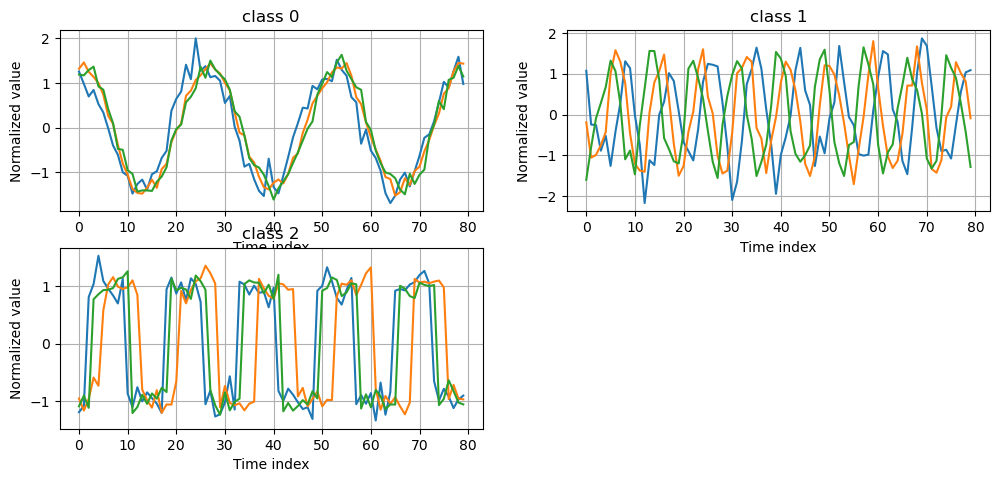

In [24]:
# Visualize the three types of signals
plt.figure(figsize=(12, 8))
for class_id in range(3):
    idx = np.where(y_ts_train == class_id)[0]
    plt.subplot(3,2,class_id+1)
    plt.plot(X_ts_train[idx[0:3], 0].T)
    plt.title(f"class {class_id}")
    plt.xlabel("Time index")
    plt.ylabel("Normalized value")
    plt.grid(True)
plt.show()

## 9. Building blocks for a 1D CNN

We implement:

1. `Conv1D`
2. `MaxPool1D`
3. `ReLU`
4. `Flatten`
5. `Dense`
6. `SoftmaxCrossEntropy`

The structure mirrors the 2D CNN, but the filter moves along one time axis.

In [8]:
def im2col_1d(X, kernel_size, stride=1, padding=0):
    '''Convert time-series batches into columns of local 1D patches.

    X has shape (N, C, T).
    Output has shape (C * kernel_size, N * T_out).
    '''
    N, C, T = X.shape

    if padding > 0:
        X_pad = np.pad(X, ((0, 0), (0, 0), (padding, padding)), mode="constant")
    else:
        X_pad = X

    T_pad = X_pad.shape[2]
    T_out = (T_pad - kernel_size) // stride + 1
    cols = np.zeros((C * kernel_size, N * T_out))

    col_idx = 0
    for n in range(N):
        for i in range(T_out):
            start = i * stride
            patch = X_pad[n, :, start:start + kernel_size]
            cols[:, col_idx] = patch.reshape(-1)
            col_idx += 1

    return cols, T_out


def col2im_1d(cols, X_shape, kernel_size, stride=1, padding=0):
    N, C, T = X_shape
    T_pad = T + 2 * padding
    T_out = (T_pad - kernel_size) // stride + 1

    X_pad_grad = np.zeros((N, C, T_pad))
    col_idx = 0

    for n in range(N):
        for i in range(T_out):
            start = i * stride
            patch_grad = cols[:, col_idx].reshape(C, kernel_size)
            X_pad_grad[n, :, start:start + kernel_size] += patch_grad
            col_idx += 1

    if padding > 0:
        return X_pad_grad[:, :, padding:-padding]
    return X_pad_grad

In [9]:
class Conv1D:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, seed=0):
        rng = np.random.default_rng(seed)
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        fan_in = in_channels * kernel_size
        fan_out = out_channels * kernel_size
        limit = np.sqrt(6.0 / (fan_in + fan_out))
        self.W = rng.uniform(-limit, limit, size=(out_channels, in_channels, kernel_size))
        self.b = np.zeros((out_channels, 1))

    def forward(self, X):
        self.X_shape = X.shape
        self.X_cols, self.T_out = im2col_1d(X, self.kernel_size, self.stride, self.padding)
        W_cols = self.W.reshape(self.out_channels, -1)
        out_cols = W_cols @ self.X_cols + self.b

        N = X.shape[0]
        out = out_cols.reshape(self.out_channels, N, self.T_out)
        out = out.transpose(1, 0, 2)
        return out

    def backward(self, dout):
        N = dout.shape[0]
        dout_cols = dout.transpose(1, 0, 2).reshape(self.out_channels, -1)

        self.dW = dout_cols @ self.X_cols.T
        self.dW = self.dW.reshape(self.W.shape) / N
        self.db = np.sum(dout_cols, axis=1, keepdims=True) / N

        W_cols = self.W.reshape(self.out_channels, -1)
        dX_cols = W_cols.T @ dout_cols
        dX = col2im_1d(dX_cols, self.X_shape, self.kernel_size, self.stride, self.padding)
        return dX

    def step(self, learning_rate):
        self.W -= learning_rate * self.dW
        self.b -= learning_rate * self.db


class MaxPool1D:
    def __init__(self, pool_size=2, stride=2):
        self.pool_size = pool_size
        self.stride = stride

    def forward(self, X):
        self.X = X
        N, C, T = X.shape
        T_out = (T - self.pool_size) // self.stride + 1
        out = np.zeros((N, C, T_out))
        self.max_indices = {}

        for n in range(N):
            for c in range(C):
                for i in range(T_out):
                    start = i * self.stride
                    window = X[n, c, start:start + self.pool_size]
                    out[n, c, i] = np.max(window)
                    self.max_indices[(n, c, i)] = np.argmax(window)
        return out

    def backward(self, dout):
        X = self.X
        dX = np.zeros_like(X)
        N, C, T_out = dout.shape

        for n in range(N):
            for c in range(C):
                for i in range(T_out):
                    start = i * self.stride
                    max_i = self.max_indices[(n, c, i)]
                    dX[n, c, start + max_i] += dout[n, c, i]
        return dX

    def step(self, learning_rate):
        pass

## 10. A small 1D CNN model

The time-series model uses:

\[
\text{Input signal}
\rightarrow \text{Conv1D}
\rightarrow \text{ReLU}
\rightarrow \text{MaxPool1D}
\rightarrow \text{Flatten}
\rightarrow \text{Dense}
\rightarrow \text{Softmax}.
\]

With input length \(T=80\), kernel size 7, and valid convolution, the convolution output length is

\[
80 - 7 + 1 = 74.
\]

Max pooling with pool size 2 gives length 37. With 12 filters, the dense layer receives

\[
12 \cdot 37 = 444
\]

features.

In [10]:
class SimpleCNN1D:
    def __init__(self, signal_length=80, num_classes=3, seed=0):
        conv_filters = 12
        kernel_size = 7
        conv_length = signal_length - kernel_size + 1
        pooled_length = conv_length // 2

        self.layers = [
            Conv1D(in_channels=1, out_channels=conv_filters, kernel_size=kernel_size, seed=seed),
            ReLU(),
            MaxPool1D(pool_size=2, stride=2),
            Flatten(),
            Dense(in_features=conv_filters * pooled_length, out_features=num_classes, seed=seed + 1),
        ]
        self.loss_fn = SoftmaxCrossEntropy()

    def forward(self, X):
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def loss(self, logits, y):
        return self.loss_fn.forward(logits, y)

    def backward(self):
        grad = self.loss_fn.backward()
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

    def step(self, learning_rate):
        for layer in self.layers:
            layer.step(learning_rate)

    def predict(self, X):
        logits = self.forward(X)
        return np.argmax(logits, axis=1)

In [11]:
def train_cnn1d(model, X_train, y_train, X_test=None, y_test=None,
                epochs=20, batch_size=32, learning_rate=0.05, seed=0):
    history = {
        "train_loss": [],
        "train_acc": [],
        "test_acc": [],
    }

    for epoch in range(epochs):
        batch_losses = []
        batch_accs = []

        for Xb, yb in get_minibatches(X_train, y_train, batch_size, seed=seed + epoch):
            logits = model.forward(Xb)
            loss = model.loss(logits, yb)
            model.backward()
            model.step(learning_rate)

            batch_losses.append(loss)
            batch_accs.append(accuracy_from_logits(logits, yb))

        train_loss = float(np.mean(batch_losses))
        train_acc = float(np.mean(batch_accs))
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        if X_test is not None and y_test is not None:
            test_logits = model.forward(X_test)
            test_acc = accuracy_from_logits(test_logits, y_test)
            history["test_acc"].append(float(test_acc))
            print(
                f"Epoch {epoch + 1}/{epochs}: "
                f"loss={train_loss:.4f}, train_acc={train_acc:.3f}, test_acc={test_acc:.3f}"
            )
        else:
            print(f"Epoch {epoch + 1}/{epochs}: loss={train_loss:.4f}, train_acc={train_acc:.3f}")

    return history

In [25]:
ts_cnn = SimpleCNN1D(signal_length=80, num_classes=3, seed=5)

history_ts = train_cnn1d(
    ts_cnn,
    X_ts_train,
    y_ts_train,
    X_ts_test,
    y_ts_test,
    epochs=8,
    batch_size=32,
    learning_rate=0.05,
    seed=100,
)

Epoch 1/8: loss=1.1072, train_acc=0.406, test_acc=0.333
Epoch 2/8: loss=0.9860, train_acc=0.537, test_acc=0.583
Epoch 3/8: loss=0.8610, train_acc=0.688, test_acc=0.667
Epoch 4/8: loss=0.7312, train_acc=0.756, test_acc=0.889
Epoch 5/8: loss=0.6060, train_acc=0.894, test_acc=0.833
Epoch 6/8: loss=0.5129, train_acc=0.875, test_acc=0.889
Epoch 7/8: loss=0.4328, train_acc=0.938, test_acc=0.972
Epoch 8/8: loss=0.3720, train_acc=1.000, test_acc=0.944


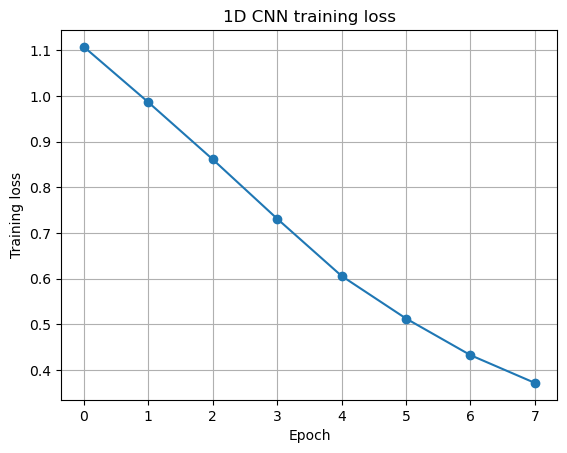

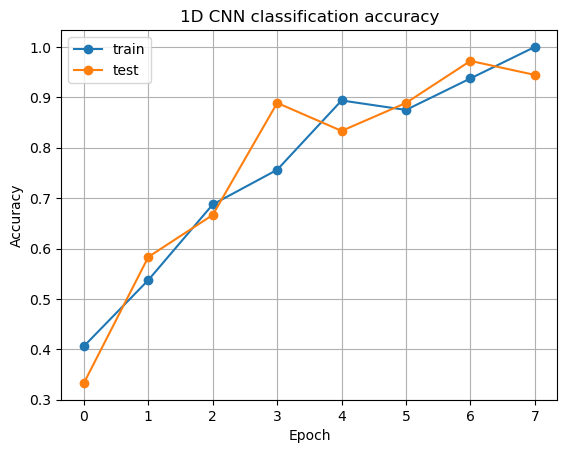

In [26]:
plt.figure()
plt.plot(history_ts["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("1D CNN training loss")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history_ts["train_acc"], marker="o", label="train")
plt.plot(history_ts["test_acc"], marker="o", label="test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("1D CNN classification accuracy")
plt.grid(True)
plt.legend()
plt.show()

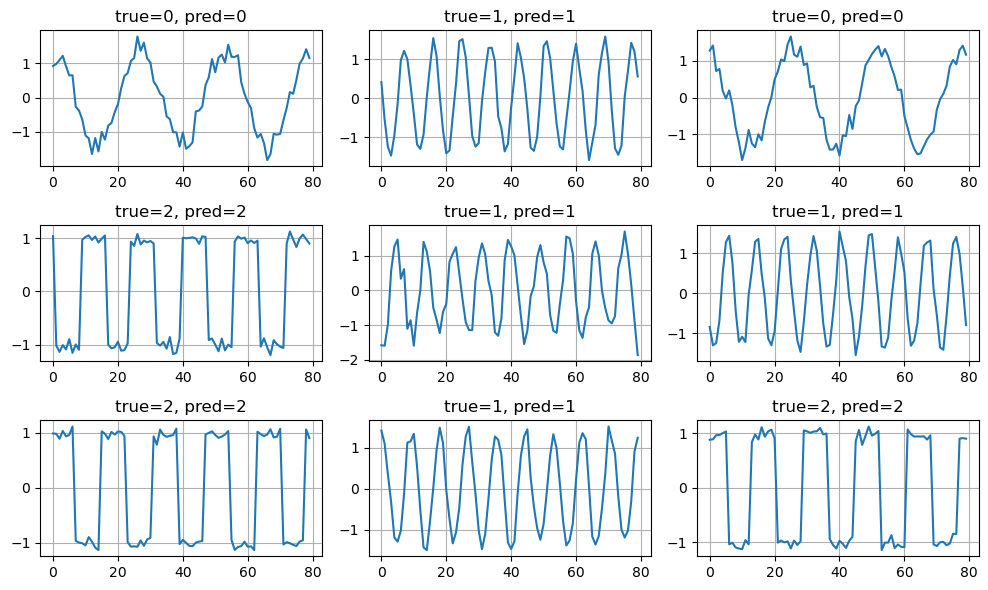

In [27]:
# Show several test predictions.

preds_ts = ts_cnn.predict(X_ts_test[:9])

plt.figure(figsize=(10, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.plot(X_ts_test[i, 0])
    plt.title(f"true={y_ts_test[i]}, pred={preds_ts[i]}")
    plt.grid(True)
plt.tight_layout()
plt.show()

## 11. Summary

This notebook implemented convolutional neural networks from scratch using NumPy.

For the **2D MNIST example**, the CNN used spatial filters to learn local image patterns. The main operations were:

- 2D convolution,
- ReLU activation,
- 2D max pooling,
- flattening,
- dense classification,
- softmax cross-entropy.

For the **1D time-series example**, the CNN used temporal filters to learn local signal patterns. The main operations were analogous:

- 1D convolution,
- ReLU activation,
- 1D max pooling,
- flattening,
- dense classification,
- softmax cross-entropy.

The key conceptual point is that CNNs are not tied to images. They are useful whenever local patterns repeat across an axis:

- across height and width for images,
- across time for time series,
- across position for sequences.

In practice, you would usually use a framework such as PyTorch, TensorFlow, or JAX for speed, automatic differentiation, GPU support, and numerical stability. But implementing the model with NumPy makes the forward and backward passes explicit.